# Experiment 10: fast grayscale ResNet50 toy model

Train one small grayscale-specific ResNet50 using a fixed 70/15/15 case-clustered split (28/6/6 patients). The artifact is intended for an experimental RGB/grayscale comparison in the research GUI, not as the project's validated model.

Research and educational use only. This model must not be used for diagnosis or clinical decision-making.

In [4]:
from __future__ import annotations

import hashlib
import json
import os
import random
import shutil
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
)
from tensorflow import keras

SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
HEAD_EPOCHS = 3
FINE_TUNE_EPOCHS = 2
HEAD_LEARNING_RATE = 1e-3
FINE_TUNE_LEARNING_RATE = 1e-5
THRESHOLD = 0.5

DATASET_ROOT = Path(os.environ.get('HISTOPANTUM_COLON_ROOT', '/content/histopantum/histopantum/colon'))
SPLIT_CSV = Path(os.environ.get('HISTOPANTUM_TOY_SPLIT_CSV', '/content/toy_split_assignment.csv'))
OUTPUT_DIR = Path('/content/exp10_grayscale_toy_outputs') if Path('/content').exists() else Path('experiments/exp-10/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print({'python': sys.version, 'tensorflow': tf.__version__, 'sklearn': sklearn.__version__})

{'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]', 'tensorflow': '2.20.0', 'sklearn': '1.6.1'}


## Verify the dataset and patient-clustered split

In [5]:
def parse_patch(path: Path, label: int) -> dict:
    """Parse one HISTOPANTUM filename into case and slide identifiers."""
    slide_id, x, y = path.stem.rsplit('_', 2)
    case_parts = slide_id.split('-')
    if len(case_parts) < 3 or case_parts[0] != 'TCGA':
        raise ValueError(f'Unexpected patch filename: {path.name}')
    return {
        'path': str(path.resolve()),
        'relative_path': path.relative_to(DATASET_ROOT).as_posix(),
        'case_id': '-'.join(case_parts[:3]),
        'slide_id': slide_id,
        'label': label,
    }


candidates = [DATASET_ROOT, Path('/content/histopantum/colon'), Path('/content/colon')]
DATASET_ROOT = next((path for path in candidates if path.is_dir()), DATASET_ROOT)
assert SPLIT_CSV.is_file(), f'Toy split not found: {SPLIT_CSV}'
assert (DATASET_ROOT / 'non-tumour').is_dir() and (DATASET_ROOT / 'tumour').is_dir()

split = pd.read_csv(SPLIT_CSV)
assert split.groupby('partition')['case_id'].nunique().to_dict() == {'test': 6, 'train': 28, 'validation': 6}
assert not split['case_id'].duplicated().any()

records = []
for class_name, label in [('non-tumour', 0), ('tumour', 1)]:
    records.extend(parse_patch(path, label) for path in sorted((DATASET_ROOT / class_name).glob('*.jpg')))
manifest = pd.DataFrame(records)
partition_of = split.set_index('case_id')['partition']
assert set(manifest['case_id']) == set(partition_of.index)
manifest['partition'] = manifest['case_id'].map(partition_of)
assert len(manifest) == 27248 and manifest['case_id'].nunique() == 40

for partition in ('train', 'validation', 'test'):
    frame = manifest.loc[manifest['partition'] == partition]
    print(partition, 'cases=', frame.case_id.nunique(), 'patches=', len(frame))

train cases= 28 patches= 20123
validation cases= 6 patches= 1748
test cases= 6 patches= 5377


## RGB input pipeline and model-internal grayscale conversion

In [6]:
AUTOTUNE = tf.data.AUTOTUNE


def decode_image(path: tf.Tensor, label: tf.Tensor):
    """Decode one RGB patch; the model performs grayscale conversion."""
    image = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    image = tf.image.resize(image, IMAGE_SIZE, antialias=True)
    return tf.cast(image, tf.float32), tf.cast(label, tf.float32)


def make_dataset(frame: pd.DataFrame, training: bool) -> tf.data.Dataset:
    """Create a deterministic, patient-partitioned dataset."""
    dataset = tf.data.Dataset.from_tensor_slices((frame['path'].to_numpy(), frame['label'].to_numpy()))
    if training:
        dataset = dataset.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(decode_image, num_parallel_calls=AUTOTUNE, deterministic=True)
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)


def build_model() -> tuple[keras.Model, str]:
    """Build ResNet50 with a fixed, serializable luminance conversion."""
    inputs = keras.Input(shape=(*IMAGE_SIZE, 3), name='rgb_image')
    grayscale_layer = keras.layers.Conv2D(
        1, 1, use_bias=False, trainable=False, name='rgb_to_grayscale'
    )
    gray = grayscale_layer(inputs)
    gray_rgb = keras.layers.Concatenate(name='repeat_grayscale')([gray, gray, gray])
    augmentation = keras.Sequential([
        keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
        keras.layers.RandomRotation(0.25, fill_mode='reflect', seed=SEED),
        keras.layers.RandomZoom(0.10, fill_mode='reflect', seed=SEED),
        keras.layers.RandomContrast(0.10, seed=SEED),
    ], name='training_augmentation')
    x = augmentation(gray_rgb)
    x = keras.layers.Lambda(keras.applications.resnet50.preprocess_input, name='caffe_preprocessing')(x)
    backbone = keras.applications.ResNet50(
        include_top=False, weights='imagenet', input_shape=(*IMAGE_SIZE, 3), pooling='avg'
    )
    backbone.trainable = False
    x = backbone(x, training=False)
    x = keras.layers.Dropout(0.30, seed=SEED)(x)
    outputs = keras.layers.Dense(1, activation='sigmoid', name='tumour_probability')(x)
    model = keras.Model(inputs, outputs, name='histopantum_grayscale_resnet50_toy')
    luminance = np.array([[[[0.2989], [0.5870], [0.1140]]]], dtype=np.float32)
    grayscale_layer.set_weights([luminance])
    return model, backbone.name


def compile_model(model: keras.Model, learning_rate: float) -> None:
    """Compile the binary model with fixed metrics."""
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[keras.metrics.BinaryAccuracy(name='accuracy'), keras.metrics.AUC(name='roc_auc')],
    )

## Train three frozen-head epochs and two short fine-tuning epochs

In [7]:
train_frame = manifest.loc[manifest['partition'] == 'train'].reset_index(drop=True)
validation_frame = manifest.loc[manifest['partition'] == 'validation'].reset_index(drop=True)
test_frame = manifest.loc[manifest['partition'] == 'test'].reset_index(drop=True)
assert set(train_frame.case_id).isdisjoint(validation_frame.case_id)
assert set(train_frame.case_id).isdisjoint(test_frame.case_id)
assert set(validation_frame.case_id).isdisjoint(test_frame.case_id)

train_ds = make_dataset(train_frame, training=True)
validation_ds = make_dataset(validation_frame, training=False)
test_ds = make_dataset(test_frame, training=False)

model, backbone_name = build_model()
custom_objects = {'preprocess_input': keras.applications.resnet50.preprocess_input}
frozen_path = OUTPUT_DIR / 'grayscale_resnet50_toy_frozen.keras'
compile_model(model, HEAD_LEARNING_RATE)
frozen_history = model.fit(
    train_ds, validation_data=validation_ds, epochs=HEAD_EPOCHS,
    callbacks=[keras.callbacks.ModelCheckpoint(frozen_path, monitor='val_loss', save_best_only=True)],
    verbose=2,
)

model = keras.models.load_model(frozen_path, custom_objects=custom_objects)
backbone = model.get_layer(backbone_name)
backbone.trainable = True
for layer in backbone.layers:
    layer.trainable = layer.name.startswith('conv5_') and not isinstance(layer, keras.layers.BatchNormalization)
assert any(layer.trainable for layer in backbone.layers)
fine_path = OUTPUT_DIR / 'grayscale_resnet50_toy_fine_tuned.keras'
compile_model(model, FINE_TUNE_LEARNING_RATE)
fine_history = model.fit(
    train_ds, validation_data=validation_ds, epochs=FINE_TUNE_EPOCHS,
    callbacks=[keras.callbacks.ModelCheckpoint(fine_path, monitor='val_loss', save_best_only=True)],
    verbose=2,
)

candidates = {'frozen': frozen_path, 'fine_tuned': fine_path}
validation_losses = {}
for phase, path in candidates.items():
    candidate = keras.models.load_model(path, custom_objects=custom_objects)
    validation_losses[phase] = candidate.evaluate(validation_ds, return_dict=True, verbose=0)['loss']
selected_phase = min(validation_losses, key=validation_losses.get)
model = keras.models.load_model(candidates[selected_phase], custom_objects=custom_objects)
final_model_path = OUTPUT_DIR / 'grayscale_resnet50_toy.keras'
model.save(final_model_path)
print('Selected phase:', selected_phase, validation_losses)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
629/629 - 106s - 169ms/step - accuracy: 0.9168 - loss: 0.2084 - roc_auc: 0.9716 - val_accuracy: 0.9045 - val_loss: 0.2291 - val_roc_auc: 0.9711
Epoch 2/3
629/629 - 101s - 160ms/step - accuracy: 0.9446 - loss: 0.1488 - roc_auc: 0.9846 - val_accuracy: 0.9108 - val_loss: 0.1927 - val_roc_auc: 0.9804
Epoch 3/3
629/629 - 103s - 164ms/step - accuracy: 0.9467 - loss: 0.1393 - roc_auc: 0.9865 - val_accuracy: 0.9233 - val_loss: 0.1717 - val_roc_auc: 0.9812
Epoch 1/2
629/629 - 151s - 241ms/step - accuracy: 0.9608 - loss: 0.1062 - roc_auc: 0.9918 - val_accuracy: 0.9457 - val_loss: 0.1442 - val_roc_auc: 0.9876
Epoch 2/2
629/629 - 135s - 214ms/step - accuracy: 0.9718 - loss: 0.0783 - roc_auc: 0.9949 - val_accuracy: 0.9479 - val_loss: 0.1267 - val_roc_auc: 0.9892
Selected phase: fine_tuned {'frozen': 0.17170239984989166, 'fine_tuned': 0.12669125199317932}


## Evaluate once on the six patient-clustered test cases

In [8]:
probability = model.predict(test_ds, verbose=1).reshape(-1)
true = test_frame['label'].to_numpy(dtype=int)
prediction = (probability >= THRESHOLD).astype(int)
predictions = test_frame[['relative_path', 'case_id', 'slide_id', 'label']].copy()
predictions['probability'] = probability
predictions['prediction'] = prediction
predictions.to_csv(OUTPUT_DIR / 'grayscale_resnet50_toy_test_predictions.csv', index=False)

metrics = {
    'accuracy': accuracy_score(true, prediction),
    'balanced_accuracy': balanced_accuracy_score(true, prediction),
    'precision': precision_score(true, prediction, zero_division=0),
    'sensitivity': recall_score(true, prediction, zero_division=0),
    'specificity': recall_score(true, prediction, pos_label=0, zero_division=0),
    'f1': f1_score(true, prediction, zero_division=0),
    'roc_auc': roc_auc_score(true, probability),
    'confusion_matrix': confusion_matrix(true, prediction).tolist(),
    'threshold': THRESHOLD,
    'cases': int(test_frame.case_id.nunique()),
    'patches': len(test_frame),
}
with (OUTPUT_DIR / 'grayscale_resnet50_toy_test_metrics.json').open('w', encoding='utf-8') as handle:
    json.dump(metrics, handle, indent=2)
display(pd.DataFrame([{key: value for key, value in metrics.items() if key != 'confusion_matrix'}]))

case_rows = []
for case_id, group in predictions.groupby('case_id'):
    case_true = group.label.to_numpy(dtype=int)
    case_pred = group.prediction.to_numpy(dtype=int)
    case_probability = group.probability.to_numpy(dtype=float)
    has_non_tumour = np.any(case_true == 0)
    has_tumour = np.any(case_true == 1)
    case_rows.append({
        'case_id': case_id, 'patches': len(group),
        'accuracy': accuracy_score(case_true, case_pred),
        'balanced_accuracy': balanced_accuracy_score(case_true, case_pred) if has_non_tumour and has_tumour else np.nan,
        'f1': f1_score(case_true, case_pred, zero_division=0),
        'roc_auc': roc_auc_score(case_true, case_probability) if has_non_tumour and has_tumour else np.nan,
    })
pd.DataFrame(case_rows).to_csv(OUTPUT_DIR / 'grayscale_resnet50_toy_case_metrics.csv', index=False)

169/169 ━━━━━━━━━━━━━━━━━━━━ 30s 167ms/step


,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,roc_auc,threshold,cases,patches
0,0.764553,0.797861,0.948481,0.652134,0.943587,0.772874,0.93717,0.5,6,5377


## Export quick figures and compact evidence

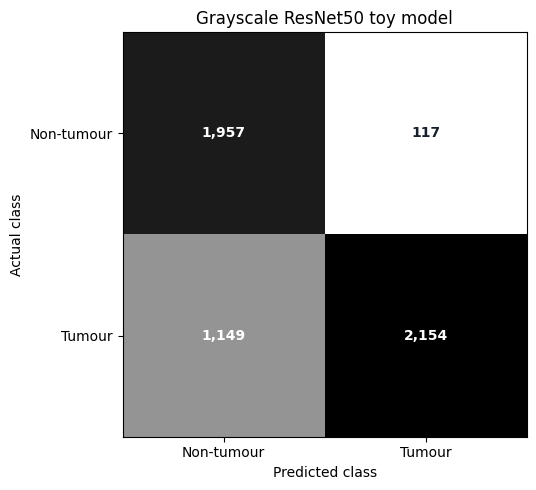

Model: /content/exp10_grayscale_toy_outputs/grayscale_resnet50_toy.keras
Compact evidence: /content/exp10_grayscale_toy_evidence.zip


In [9]:
matrix = np.asarray(metrics['confusion_matrix'])
fig, ax = plt.subplots(figsize=(5.6, 5.0))
image = ax.imshow(matrix, cmap='Greys')
ax.grid(False)
for row in range(2):
    for column in range(2):
        color = 'white' if matrix[row, column] > matrix.max() / 2 else '#17202A'
        ax.text(column, row, f'{matrix[row, column]:,}', ha='center', va='center', color=color, weight='bold')
ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=['Non-tumour', 'Tumour'],
       yticklabels=['Non-tumour', 'Tumour'], xlabel='Predicted class', ylabel='Actual class',
       title='Grayscale ResNet50 toy model')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'grayscale_resnet50_toy_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

def sha256_file(path: Path) -> str:
    """Return a file's lowercase SHA-256 digest."""
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


manifest_document = {
    'experiment': 10, 'purpose': 'toy grayscale model for research GUI comparison',
    'architecture': 'resnet50', 'input': 'RGB accepted; fixed model-internal grayscale conversion',
    'model_file': final_model_path.name, 'model_sha256': sha256_file(final_model_path),
    'model_bytes': final_model_path.stat().st_size, 'selected_phase': selected_phase,
    'split': {'train_cases': 28, 'validation_cases': 6, 'test_cases': 6},
    'epochs': {'frozen_head': HEAD_EPOCHS, 'fine_tuning': FINE_TUNE_EPOCHS},
    'threshold': THRESHOLD,
    'limitations': ['Toy internal model', 'Not clinical validation', 'Not for diagnosis'],
}
with (OUTPUT_DIR / 'grayscale_resnet50_toy_manifest.json').open('w', encoding='utf-8') as handle:
    json.dump(manifest_document, handle, indent=2)

compact_dir = Path('/content/exp10_grayscale_toy_compact')
if compact_dir.exists():
    shutil.rmtree(compact_dir)
compact_dir.mkdir(parents=True)
for artifact in OUTPUT_DIR.iterdir():
    if artifact.is_file() and artifact.suffix != '.keras':
        shutil.copy2(artifact, compact_dir / artifact.name)
archive = Path(shutil.make_archive('/content/exp10_grayscale_toy_evidence', 'zip', compact_dir))
print('Model:', final_model_path)
print('Compact evidence:', archive)

In [10]:
!zip -r /content/exp10_grayscale_toy_outputs.zip /content/exp10_grayscale_toy_outputs


  adding: content/exp10_grayscale_toy_outputs/ (stored 0%)
  adding: content/exp10_grayscale_toy_outputs/grayscale_resnet50_toy_fine_tuned.keras (deflated 7%)
  adding: content/exp10_grayscale_toy_outputs/grayscale_resnet50_toy_test_predictions.csv (deflated 90%)
  adding: content/exp10_grayscale_toy_outputs/grayscale_resnet50_toy_test_metrics.json (deflated 42%)
  adding: content/exp10_grayscale_toy_outputs/grayscale_resnet50_toy.keras (deflated 7%)
  adding: content/exp10_grayscale_toy_outputs/grayscale_resnet50_toy_manifest.json (deflated 43%)
  adding: content/exp10_grayscale_toy_outputs/grayscale_resnet50_toy_frozen.keras (deflated 8%)
  adding: content/exp10_grayscale_toy_outputs/grayscale_resnet50_toy_case_metrics.csv (deflated 43%)
  adding: content/exp10_grayscale_toy_outputs/grayscale_resnet50_toy_confusion_matrix.png (deflated 23%)


## GUI boundary

This toy model may be shown beside the project's primary RGB model under an **Experimental RGB/grayscale comparison** heading. The models use different training protocols and evaluation splits, so their scores are visual demonstrations rather than a fair model comparison. Neither score is a diagnosis.